In [1]:
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [2]:
df = pd.DataFrame({
    'Hours_Studied': [1, 2, 3, 4, 5, 6, 7, 8],
    'Attendance':    [60, 65, 70, 75, 80, 85, 90, 95],  # in percentage
    'Marks':         [42, 48, 53, 61, 66, 72, 79, 83]
})

In [3]:
X = df[['Hours_Studied', 'Attendance']]

In [4]:
y = df['Marks']

In [5]:
model = LinearRegression()
model.fit(X, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](2,)","[0.23,1.15]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](2,)","['Hours_Studied','Attendance']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-27.46
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,2
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


In [6]:
y_pred = model.predict(X)

In [7]:
residuals = y - y_pred

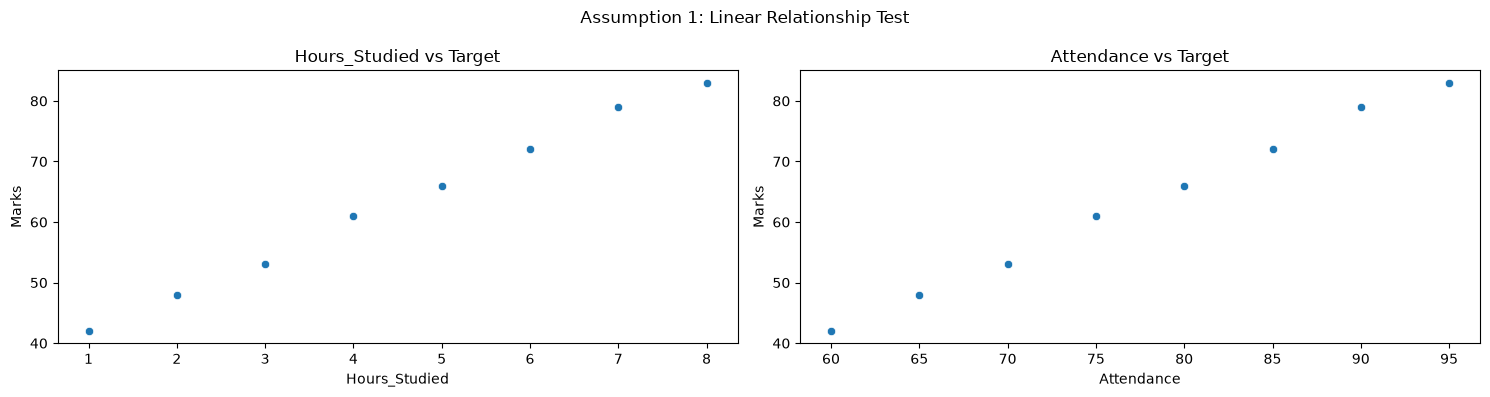

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4))
fig.suptitle('Assumption 1: Linear Relationship Test')

for i, col in enumerate(X.columns):
    sns.scatterplot(data=df, x=col, y=df['Marks'], ax=axes[i])
    axes[i].set_title(f'{col} vs Target')

plt.tight_layout()
plt.show()

In [13]:
print("--- Assumption 2: Multicollinearity Evaluation ---")
X = sm.add_constant(df[['Hours_Studied', 'Attendance']])
vif = pd.DataFrame()
vif["Feature"] = X.columns

vif["VIF"] = [
    variance_inflation_factor(X.values, i)
    for i in range(X.shape[1])
]

print(vif)
pd.set_option("display.precision", 20)

print(df.corr())

--- Assumption 2: Multicollinearity Evaluation ---
         Feature  VIF
0          const  0.0
1  Hours_Studied  inf
2     Attendance  inf
                        Hours_Studied              Attendance  \
Hours_Studied  1.00000000000000000000  1.00000000000000000000   
Attendance     1.00000000000000000000  1.00000000000000000000   
Marks          0.99867986741125380767  0.99867986741125369665   

                                Marks  
Hours_Studied  0.99867986741125380767  
Attendance     0.99867986741125369665  
Marks          1.00000000000000000000  


C:\Users\aniru\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\regression\linear_model.py:1782: RuntimeWarning: divide by zero encountered in scalar divide
  return 1 - self.ssr/self.centered_tss
C:\Users\aniru\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


In [11]:
print(X)

   const  Hours_Studied  Attendance
0    1.0              1          60
1    1.0              2          65
2    1.0              3          70
3    1.0              4          75
4    1.0              5          80
5    1.0              6          85
6    1.0              7          90
7    1.0              8          95


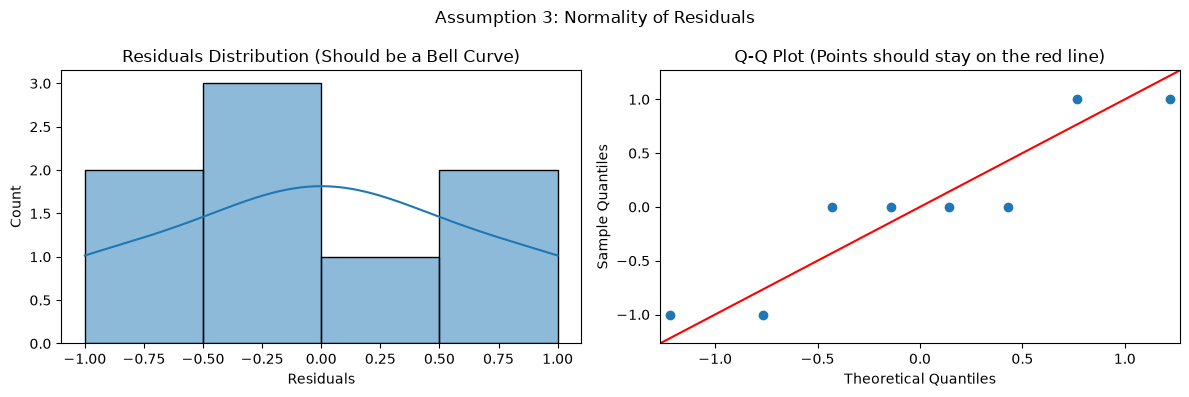

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Assumption 3: Normality of Residuals')

# Technique A: KDE / Distribution Plot
sns.histplot(residuals, kde=True, ax=axes[0])
axes[0].set_title('Residuals Distribution (Should be a Bell Curve)')
axes[0].set_xlabel('Residuals')

# Technique B: Q-Q Plot
sm.qqplot(residuals, line='45', ax=axes[1])
axes[1].set_title('Q-Q Plot (Points should stay on the red line)')

plt.tight_layout()
plt.show()


Look at the Homoscedasticity plot: Ensure the point cloud is evenly spread with no funnel pattern.


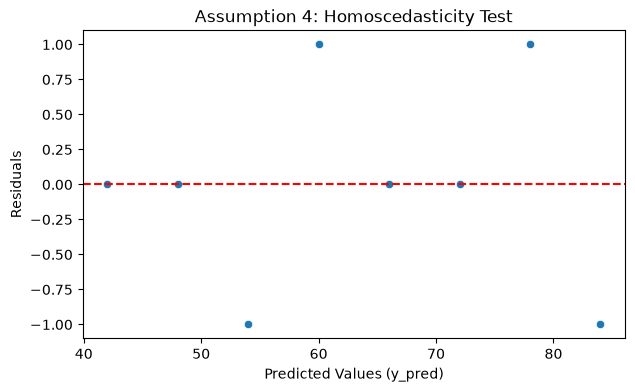

In [29]:
plt.figure(figsize=(7, 4))
sns.scatterplot(x=y_pred, y=residuals)
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Assumption 4: Homoscedasticity Test')
plt.xlabel('Predicted Values (y_pred)')
plt.ylabel('Residuals')
print("\nLook at the Homoscedasticity plot: Ensure the point cloud is evenly spread with no funnel pattern.")
plt.show()

Look at the Auto-Correlation plot: Points should fluctuate randomly without distinct waves or cycles.


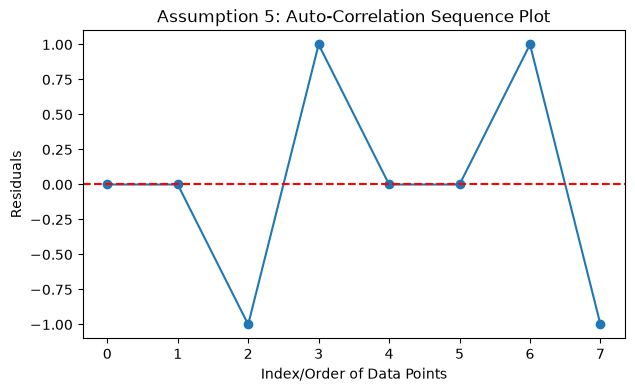

In [30]:
plt.figure(figsize=(7, 4))
plt.plot(residuals.values, marker='o', linestyle='-')
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Assumption 5: Auto-Correlation Sequence Plot')
plt.xlabel('Index/Order of Data Points')
plt.ylabel('Residuals')
print("Look at the Auto-Correlation plot: Points should fluctuate randomly without distinct waves or cycles.")
plt.show()